# Location Mention Recognition (LMR) – Exploratory Data Analysis

## Objective
Build a system that extracts location mentions from disaster-related tweets.

---

## Dataset
- Source: Microsoft Location Mention Recognition Challenge
- Task: Extract location mentions from disaster-related tweets

## 1. Data Exploration (Structural Understanding)

In this section, we examine the raw dataset to understand its structure and content without performing any modifications.

The objective is to:
- Inspect dataset dimensions
- Review column names and data types
- Identify missing values
- Detect duplicate records
- Understand the target variable structure

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the training data
train_path = "../data/raw/Train_1.csv"
train = pd.read_csv(train_path)


# First few rows
train.head()

,tweet_id,text,location
0,ID_1001136212718088192,NaN,EllicottCity
1,ID_1001136696589631488,"Flash floods struck a Maryland city on Sunday,...",Maryland
2,ID_1001136950345109504,State of emergency declared for Maryland flood...,Maryland
3,ID_1001137334056833024,Other parts of Maryland also saw significant d...,Baltimore Maryland
4,ID_1001138374923579392,"Catastrophic Flooding Slams Ellicott City, Mar...",Ellicott City Maryland


In [3]:
# Dataset shape
print("Dataset Shape:", train.shape)
print("\n")

Dataset Shape: (73072, 3)




### Dataset Dimensions

The training dataset contains **73,072 rows** and **3 columns**.

Each row represents a single tweet with:
- A unique identifier (`tweet_id`)
- The tweet text (`text`)
- The labeled location mention (`location`)

In [4]:
# Column names
print("Columns:", train.columns.tolist())
print("\n")

Columns: ['tweet_id', 'text', 'location']




In [5]:
# Data types
print("Data Types:")
print(train.dtypes)
print("\n")

Data Types:
tweet_id    object
text        object
location    object
dtype: object




### 1.1 Missing Values Analysis

Before proceeding further, we examine whether there are missing values in any of the columns.  
Missing values in the `text` or `location` fields could affect modeling and may require handling during the cleaning stage.

In [6]:
train.isna().sum()

tweet_id        0
text        56624
location    29612
dtype: int64

### Missing Values Summary

- `tweet_id`: 0 missing values  
- `text`: 56,624 missing values  
- `location`: 29,612 missing values  

This indicates a substantial proportion of missing values in both the tweet text and target variable. Further investigation is required to determine whether these represent truly empty entries or formatting inconsistencies.

### 1.2 Verifying Missing Text Entries

To better understand the missing `text` values, we inspect a few rows where the text is null.

In [7]:
# Inspect rows where text is missing
train[train["text"].isna()].head(10)

,tweet_id,text,location
0,ID_1001136212718088192,NaN,EllicottCity
6,ID_1001139323075416064,NaN,Ellicott City Maryland
7,ID_1001139644023693312,NaN,NaN
8,ID_1001140017207459840,NaN,Maryland
9,ID_1001140276377935872,NaN,Maryland
10,ID_1001140804503601152,NaN,Baltimore
11,ID_1001141041926492160,NaN,Maryland
12,ID_1001141195576258560,NaN,Ellicott Maryland
13,ID_1001141289323319296,NaN,Maryland
15,ID_1001141974148239360,NaN,NaN


### Observations on Missing Text Values

Inspection of rows with missing `text` reveals:

- Several rows contain a valid `location` but no tweet text.
- Some rows contain both missing `text` and missing `location`.

From a modeling perspective, rows without tweet text cannot be used for training since there is no input data to learn from.

This issue will need to be addressed during the data cleaning stage.

### 1.3 Quantifying Usable Training Data

To understand how much data is actually usable for modeling, we calculate the number of rows where both `text` and `location` are present.

In [8]:
usable_data = train.dropna(subset=["text", "location"])

print("Total rows:", len(train))
print("Rows with both text and location:", len(usable_data))
print("Percentage usable:", round(len(usable_data) / len(train) * 100, 2), "%")

Total rows: 73072
Rows with both text and location: 11849
Percentage usable: 16.22 %


### Usable Training Data Assessment

Out of 73,072 total rows, only 11,849 rows contain both tweet text and a labeled location.

This represents approximately 16.22% of the dataset.

Implications:

- The effective supervised training dataset is significantly smaller than the raw dataset size.
- Rows missing `text` cannot be used for model training.
- Rows missing `location` cannot contribute to supervised extraction learning.
- Data cleaning will require careful filtering to retain only valid training instances.

### 1.4 Verifying Location Alignment with Text

Since this task involves extracting location mentions from tweets, it is important to verify whether the labeled `location` value appears directly within the corresponding tweet text.

If the location does not appear verbatim in the text, this may indicate normalization differences, formatting issues, or labeling inconsistencies.

In [9]:
alignment_check = usable_data.copy()
alignment_check["location_in_text"] = alignment_check.apply(
    lambda row: str(row["location"]) in str(row["text"]),
    axis=1
)

print("Percentage where location appears verbatim in text:",
      round(alignment_check["location_in_text"].mean() * 100, 2), "%")

Percentage where location appears verbatim in text: 71.3 %


#### Location–Text Alignment Analysis

Among rows containing both text and location, approximately 71.3% of the labeled locations appear verbatim within the tweet text.

Implications:

- A significant portion (28.7%) of labeled locations do not exactly match substrings in the tweet.
- This suggests potential inconsistencies such as:
  - Formatting differences (e.g., spacing or capitalization)
  - Abbreviations or normalization variations
  - Annotation discrepancies
- The extraction task may therefore require normalization handling rather than simple substring matching.

### 1.5 Duplicate Record Check

We verify whether duplicate rows exist in the dataset, as duplicates can bias model training and evaluation.

In [10]:
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


#### Duplicate Record Assessment

No fully duplicated rows were detected in the dataset.

This indicates that there is no immediate risk of duplicated training instances biasing the model. However, further checks during cleaning may still examine partial duplicates (e.g., identical text with different labels).

## Data Exploration Findings Summary

Key observations from the structural exploration stage:

1. The dataset contains 73,072 rows and 3 columns.
2. Only 11,849 rows (16.22%) contain both tweet text and a labeled location.
3. A large portion of rows contain missing `text`, making them unusable for training.
4. Approximately 71.3% of labeled locations appear verbatim in the tweet text.
5. No fully duplicated rows were found.

These findings indicate that careful filtering and normalization will be required during the data cleaning stage.

## 2. Data Cleaning

Based on the structural exploration findings, the following cleaning steps will be performed:

1. Remove rows where `text` is missing.
2. Retain rows where `location` is missing, as they represent valid negative examples.
3. Apply minimal normalization to text and location fields.
4. Preserve raw data integrity by creating a cleaned copy.

All transformations are documented to ensure reproducibility.

### 2.1 Removing Rows with Missing Text

Rows without tweet text cannot be used for training since there is no input data. These rows will be removed.

In [11]:
cleaned = train.dropna(subset=["text"]).copy()

print("Original dataset size:", len(train))
print("After removing missing text:", len(cleaned))
print("Percentage retained:", round(len(cleaned)/len(train)*100, 2), "%")

Original dataset size: 73072
After removing missing text: 16448
Percentage retained: 22.51 %


#### Post-Filtering Dataset Size

After removing rows with missing tweet text, the dataset now contains 16,448 rows.

This represents 22.51% of the original dataset. The remaining rows are structurally usable for modeling, as they contain valid input text.

The next step is to examine how many of these rows contain labeled locations.

### 2.2 Target Availability After Cleaning

We now evaluate how many of the remaining rows contain a labeled location versus missing location values.

Rows with missing `location` are retained, as they represent valid negative examples.

In [12]:
print("Rows with location:", cleaned["location"].notna().sum())
print("Rows without location:", cleaned["location"].isna().sum())

print("Percentage with location:",
      round(cleaned["location"].notna().mean()*100, 2), "%")

Rows with location: 11849
Rows without location: 4599
Percentage with location: 72.04 %


#### Target Distribution After Cleaning

Among the 16,448 usable rows:

- 11,849 rows (72.04%) contain a labeled location.
- 4,599 rows (27.96%) contain no location label.

This distribution provides both positive and negative examples, which is beneficial for training a realistic extraction model capable of predicting when no location is present.

### 2.3 Basic Text Normalization

To ensure consistency without removing useful signals, minimal normalization will be applied:

- Convert text and location columns to string type.
- Strip leading and trailing whitespace.
- Normalize repeated spaces.

No aggressive transformations (e.g., lowercasing or punctuation removal) are applied at this stage.

In [13]:
# Convert to string (safe handling)
cleaned["text"] = cleaned["text"].astype(str)
cleaned["location"] = cleaned["location"].astype(str)

# Strip whitespace
cleaned["text"] = cleaned["text"].str.strip()
cleaned["location"] = cleaned["location"].str.strip()

# Normalize multiple spaces
cleaned["text"] = cleaned["text"].str.replace(r"\s+", " ", regex=True)
cleaned["location"] = cleaned["location"].str.replace(r"\s+", " ", regex=True)

cleaned.head()

,tweet_id,text,location
1,ID_1001136696589631488,"Flash floods struck a Maryland city on Sunday,...",Maryland
2,ID_1001136950345109504,State of emergency declared for Maryland flood...,Maryland
3,ID_1001137334056833024,Other parts of Maryland also saw significant d...,Baltimore Maryland
4,ID_1001138374923579392,"Catastrophic Flooding Slams Ellicott City, Mar...",Ellicott City Maryland
5,ID_1001138377717157888,WATCH: 1 missing after flash #FLOODING devasta...,Ellicott City Maryland


### 2.4 Re-evaluating Location Alignment

After applying minimal normalization, we reassess whether the labeled location appears verbatim in the corresponding tweet text.

This helps determine whether formatting inconsistencies were affecting alignment.

In [14]:
# Only check rows where location exists
alignment_check = cleaned[cleaned["location"] != "nan"].copy()

alignment_check["location_in_text"] = alignment_check.apply(
    lambda row: row["location"] in row["text"],
    axis=1
)

print("Updated percentage where location appears verbatim in text:",
      round(alignment_check["location_in_text"].mean() * 100, 2), "%")

Updated percentage where location appears verbatim in text: 71.31 %


#### Alignment After Normalization

The alignment rate remained effectively unchanged after normalization (71.31%).

This indicates that the mismatch between `location` and `text` is not caused by simple whitespace inconsistencies.

The remaining discrepancies are likely due to formatting differences, abbreviations, or annotation conventions. This will influence the modeling approach, as strict substring matching alone will not fully solve the task.

### 2.5 Finalizing Cleaned Dataset

We finalize the cleaned dataset by ensuring missing locations are properly represented as null values and saving the processed dataset for downstream modeling.

In [15]:
# Replace string "nan" back to actual NaN
cleaned["location"] = cleaned["location"].replace("nan", np.nan)

# Save cleaned dataset
cleaned.to_csv("../data/processed/train_clean.csv", index=False)

print("Cleaned dataset saved.")
print("Final dataset shape:", cleaned.shape)

Cleaned dataset saved.
Final dataset shape: (16448, 3)


# 3. Exploratory Data Analysis (EDA)

With the cleaned dataset prepared, we now explore the characteristics of the data through statistical summaries and visual analysis.

The objectives of this stage are:

- Understand the distribution of labeled vs unlabeled tweets
- Examine text length patterns
- Analyze the frequency of location mentions
- Identify potential modeling challenges

### 3.1 Distribution of Location Labels

We visualize the proportion of tweets that contain a location mention versus those that do not.

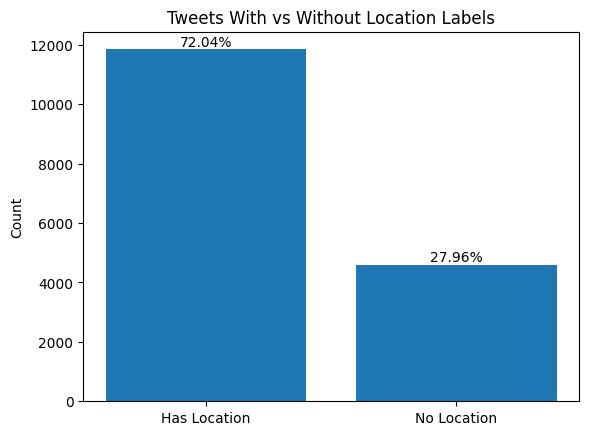

In [16]:
label_counts = cleaned["location"].notna().value_counts()
total = len(cleaned)

plt.figure()
bars = plt.bar(["Has Location", "No Location"], label_counts.values)

plt.title("Tweets With vs Without Location Labels")
plt.ylabel("Count")

# Add percentage labels above bars
for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{percentage:.2f}%",
        ha="center",
        va="bottom"
    )

plt.show()

#### * Insights

The dataset contains a higher proportion of tweets with location labels compared to those without. 

While the dataset is moderately imbalanced, the distribution remains suitable for supervised learning. The presence of a substantial number of negative examples ensures the model can learn both detection and non-detection scenarios effectively.

### 3.2 Text Length Analysis

We analyze the distribution of tweet lengths to understand input variability and potential modeling constraints such as truncation limits for transformer-based models.

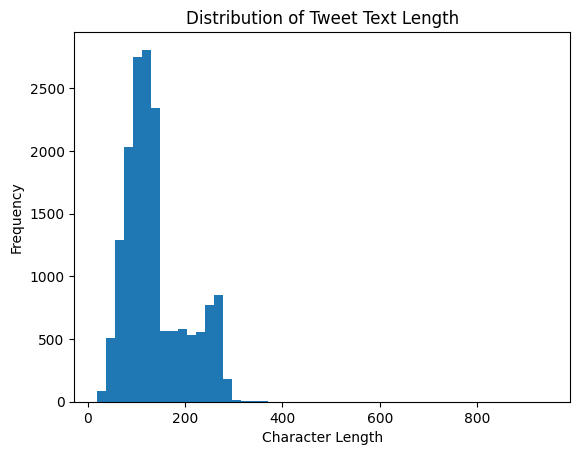

Average text length: 137.21
Maximum text length: 945
Minimum text length: 19


In [17]:
cleaned["text_length"] = cleaned["text"].apply(len)

plt.figure()
plt.hist(cleaned["text_length"], bins=50)
plt.title("Distribution of Tweet Text Length")
plt.xlabel("Character Length")
plt.ylabel("Frequency")
plt.show()

print("Average text length:", round(cleaned["text_length"].mean(), 2))
print("Maximum text length:", cleaned["text_length"].max())
print("Minimum text length:", cleaned["text_length"].min())

#### * Insights

The distribution of tweet lengths is right-skewed, with most tweets falling between 50 and 250 characters.

The presence of extreme outliers (up to 945 characters) suggests that some entries may contain extended or irregular content.

For transformer-based models, truncation strategies will likely be necessary to handle unusually long inputs while preserving meaningful context.

### 3.3 Location Frequency Analysis

We examine the most frequently occurring location labels to understand whether the dataset is dominated by specific geographic entities.

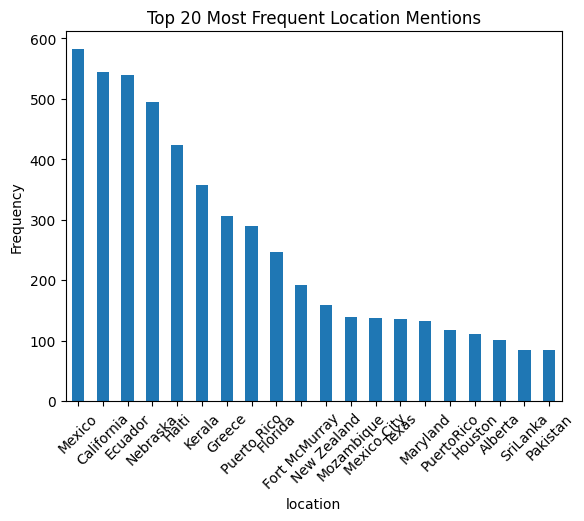

location
Mexico           582
California       544
Ecuador          539
Nebraska         495
Haiti            424
Kerala           357
Greece           306
Puerto Rico      289
Florida          247
Fort McMurray    192
New Zealand      159
Mozambique       139
Mexico City      138
Texas            135
Maryland         133
PuertoRico       118
Houston          111
Alberta          101
SriLanka          85
Pakistan          84
Name: count, dtype: int64

In [18]:
top_locations = cleaned["location"].value_counts().head(20)

plt.figure()
top_locations.plot(kind="bar")
plt.title("Top 20 Most Frequent Location Mentions")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

top_locations

#### * Insights

The dataset shows geographic concentration, with a small number of locations appearing frequently. This suggests event clustering around major disasters.

Label inconsistencies such as "Puerto Rico" and "PuertoRico" indicate formatting variation in annotations.

The frequency distribution also demonstrates a long-tail pattern, meaning the model must generalize beyond the most common locations rather than relying on memorization.

### 3.4 Text Length by Label Presence

We compare text length distributions between tweets that contain location mentions and those that do not.

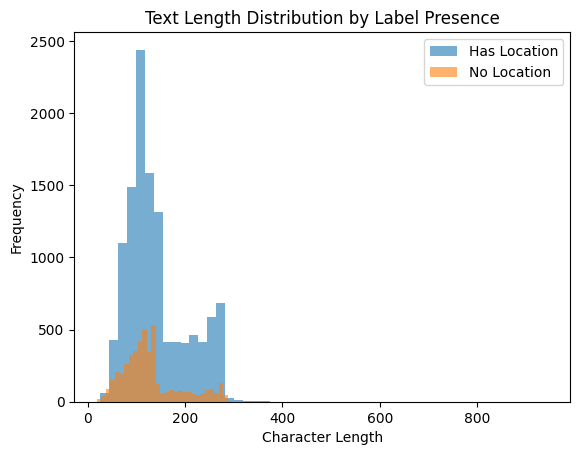

Average length (Has Location): 140.53
Average length (No Location): 128.66


In [19]:
has_location = cleaned[cleaned["location"].notna()]
no_location = cleaned[cleaned["location"].isna()]

plt.figure()
plt.hist(has_location["text_length"], bins=50, alpha=0.6, label="Has Location")
plt.hist(no_location["text_length"], bins=50, alpha=0.6, label="No Location")
plt.legend()
plt.title("Text Length Distribution by Label Presence")
plt.xlabel("Character Length")
plt.ylabel("Frequency")
plt.show()

print("Average length (Has Location):", round(has_location["text_length"].mean(), 2))
print("Average length (No Location):", round(no_location["text_length"].mean(), 2))

#### * Insights

Tweets containing location mentions are slightly longer on average compared to those without location labels. However, the distributions overlap significantly.

This suggests that text length alone is not a strong predictor of location presence. Effective modeling will require semantic understanding rather than relying on superficial features such as character count.

### 3.5 EDA Summary and Modeling Implications

Key findings from the exploratory data analysis:

1. The dataset contains both positive and negative examples in a moderately imbalanced distribution.
2. Text lengths are right-skewed, with some extreme outliers requiring truncation strategies.
3. Location labels show geographic concentration and long-tail distribution.
4. Label formatting inconsistencies exist.
5. Text length is not a strong standalone predictor of location presence.

These insights inform the modeling strategy, which will likely require:
- Context-aware transformer models
- Careful handling of label normalization
- Evaluation strategies robust to long-tail entities

# 4. Problem Framing and Modeling Strategy

Before building predictive models, it is important to clearly define the learning objective, target formulation, and evaluation approach.

This ensures that the modeling stage is aligned with the problem requirements and the structure of the dataset.

### 4.1 Problem Definition

The objective of this project is to develop a system capable of identifying location mentions within disaster-related tweets.

Given a tweet as input, the model must determine whether a location mention exists and, if so, extract the corresponding location text.

Formally:

Input: Tweet text  
Output: Location mention (string) or null if no location is present.

### 4.2 Learning Formulation

This task can be framed as a location extraction problem from short text sequences.

Unlike traditional classification tasks where the output belongs to a fixed set of categories, the target variable in this dataset is a free-form location string.

Therefore, the problem is best treated as a **text span extraction or sequence-to-sequence prediction task**, where the model learns to generate or identify location mentions directly from tweet text.

### 4.3 Modeling Challenges

The exploratory analysis revealed several challenges that influence modeling decisions:

1. Only 22.5% of the original dataset contained usable tweet text.
2. Approximately 28% of cleaned rows contain no location label.
3. Only ~71% of labeled locations appear verbatim in the tweet text.
4. Location labels exhibit formatting inconsistencies (e.g., spacing differences).
5. The dataset shows geographic concentration and long-tail distribution.

These characteristics suggest that simple rule-based extraction methods may not perform reliably.

### 4.4 Proposed Modeling Approach

To address the complexities identified during analysis, a transformer-based natural language processing model will be used.

Transformer architectures are well-suited for this task because they capture contextual relationships within text and can learn complex patterns required for entity extraction.

The modeling process will follow a progressive approach:

1. Establish a simple baseline model.
2. Implement a transformer-based extraction model.
3. Evaluate model performance and analyze prediction errors.

### 4.5 Train–Validation Strategy

To evaluate model performance during development, the cleaned dataset will be split into training and validation subsets.

A standard 80/20 split will be used:

- Training set: used to fit the model
- Validation set: used to evaluate model generalization

### 4.6 Evaluation Considerations

Since the goal is to correctly extract location mentions from tweets, model evaluation will focus on the accuracy of predicted location outputs relative to the labeled locations.

Performance analysis will include:

- Correct extraction of location mentions
- Ability to correctly predict the absence of a location
- Error analysis to identify common prediction failures

# 5. Train / Validation Split and Baseline Model

Before building models, we prepare the dataset for training and evaluation.

The cleaned dataset will be split into training and validation subsets. The training set will be used to fit the model, while the validation set will be used to evaluate model performance and generalization.

### 5.1 Feature and Target Definition

For this task:

Feature:
- Tweet text

Target:
- Location mention (string) or null if no location exists

In [20]:
# Define the feature (input) and target (output)
# X contains the tweet text
# y contains the labeled location mention

X = cleaned["text"]
y = cleaned["location"]

In [21]:
# Import the function used to split datasets
from sklearn.model_selection import train_test_split

# Split the dataset into training and validation sets
# 80% of the data will be used for training
# 20% will be used for validation

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the number of samples in each set
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 13158
Validation samples: 3290


In [ ]:
# Import regular expressions library for pattern matching
import re

# Define a simple rule-based function to extract potential locations
# The rule identifies sequences of capitalized words

def extract_location_rule(text):
    matches = re.findall(r'\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)*', text)
    return matches[0] if matches else None


# Apply the rule-based extractor to the validation set
baseline_predictions = X_val.apply(extract_location_rule)

# Display the first few predictions
baseline_predictions.head()

70253       Were
46080    Indiain
9325      Kerala
41740      Death
10751    Corpses
Name: text, dtype: object

In [23]:
# Calculate how many predictions exactly match the labeled location
baseline_correct = (baseline_predictions == y_val).sum()

# Compute a simple baseline accuracy metric
baseline_accuracy = baseline_correct / len(y_val)

print("Baseline exact matches:", baseline_correct)
print("Baseline accuracy:", baseline_accuracy)

Baseline exact matches: 223
Baseline accuracy: 0.06778115501519758


#### Baseline Model Performance

The rule-based baseline achieved an exact match accuracy of approximately **6.78%** on the validation set.

This low performance is expected due to the simplicity of the heuristic approach. The rule extracts capitalized word sequences, which may not always correspond to the labeled location mention. Additionally, strict exact matching penalizes small formatting differences.

Despite its limitations, this baseline provides a useful performance reference point for evaluating more advanced models.

---
# Next Steps

The dataset has been explored, cleaned, and analyzed. Key data characteristics and modeling implications have been documented.

The next stage of the project will focus on establishing baseline models in `03_baseline_model.ipynb`, beginning with simple heuristics and classical NLP approaches before moving to transformer-based methods.